<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EB%A8%B8%ED%95%80vs%EC%B9%98%EC%99%80%EC%99%80_%EB%B6%84%EB%A5%98%EA%B3%B5%EB%B6%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# numpy 1.x + imgaug 설치
!pip uninstall -y numpy imgaug
!pip install "numpy<2.0" "imgaug==0.4.0"

# 런타임 재시작 필요 (중요!)
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have num

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 드라이브 경로에 있는 zip 압축 해제
!unzip "/content/drive/MyDrive/머핀vs치와와.zip" -d "/content/muffin_vs_chihuahua"

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_3_674.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_3_396.jpg  
  inflating: /content/muffin_vs_chihuahua/6/train/muffin/img_4_396.jpg  
  inflating: /content/muffin_vs_chihuahua/6/train/muffin/img_4_793.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_2_752.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_2_1044.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_3_333.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_2_792.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_1_103.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_3_68.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_3_129.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_0_60.jpg  
  inflating: /content/muffin_vs_chihuahua/6/val/chihuahua/img_3_968.jpg  
  inf

In [ ]:
!ls  /content/muffin_vs_chihuahua/6/

test  train  val


In [ ]:
import os         # 파일/디렉토리 경로 작업용
import glob       # 특정 패턴의 파일경로를 쉽게 찾기 위해 사용
import numpy as np # 수치 계산, 배열/행렬 연산 라이브러리
import matplotlib.pyplot as plt
from PIL import Image # 이미지 파일을 열고 다루기 위한 라이브러리

import torch              # PyTorch 메인 라이브러리
import torch.nn as nn     # 신경망 레이어, 손실함수 등 제공
import torch.optim as optim # 최적화 알고리즘
from torch.utils.data import DataLoader, Dataset
# DataLoader: 데이터 배치를 만들어주는 도구
# Dataset: 커스텀 데이터셋 클래스 만들 때 상속받는 기본 클래스

from torchvision.utils import make_grid
# 여러 이미지를 그리드 형태로 묶어서 시각화하는 함수

from torchvision.datasets import ImageFolder
# 폴더 구조에 맞춰 이미지 데이터를 불러오는 Dataset 클래스

import torchvision.models as models
# ResNet, VGG, EfficientNet 같은 유명 CNN 모델 아키텍처와 사전학습된 가중치 제공

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else " cpu")

In [ ]:
print('Device:', device)

Device: cuda


In [ ]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """지정된 경로의 이미지를 최대 4개까지 출력합니다."""

  # 1. 출력 캔버스 크기 설정 (가로 12, 세로 3 인치)
  plt.figure(figsize=(12, 3))

  # 2. 전달받은 이미지 경로 중 앞에서부터 max_images개까지만 반복
  for i, image_path in enumerate(image_paths[:max_images]):
    # 이미지 불러오기 (Numpy 배열 형태)
    img = plt.imread(image_path)

    # subplot: 1행 max_images열 중 (i+1)번째 위치
    plt.subplot(1, max_images, i+1)

    # 이미지 출력
    plt.imshow(img)

    # 이미지 제목 표시
    plt.title(title)

    plt.axis('off')
  plt.show()

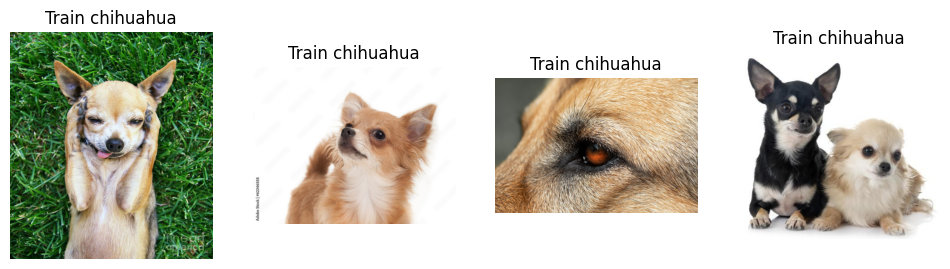

Train chihuahua 총 이미지 수:2579


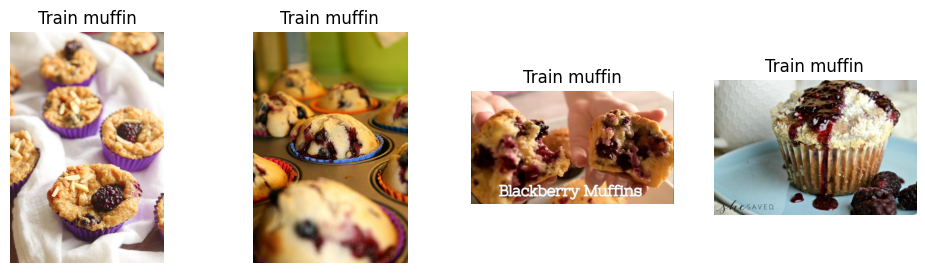

Train muffin 총 이미지 수:2224


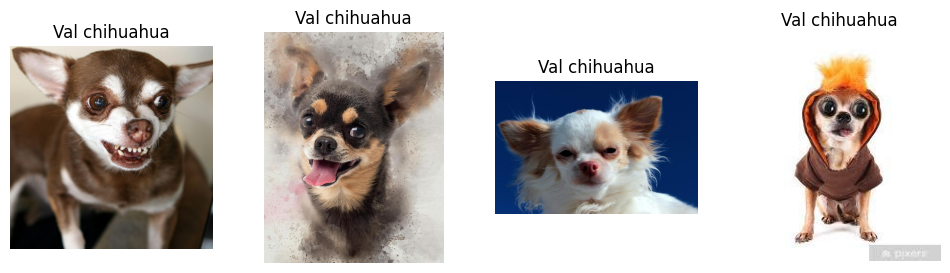

Val chihuahua 총 이미지 수:622


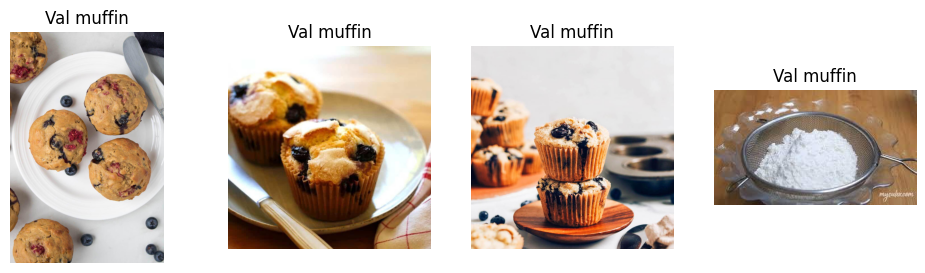

Val muffin 총 이미지 수:554


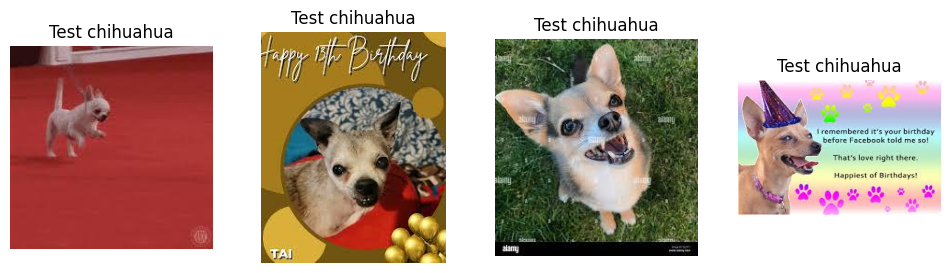

Test chihuahua 총 이미지 수:18


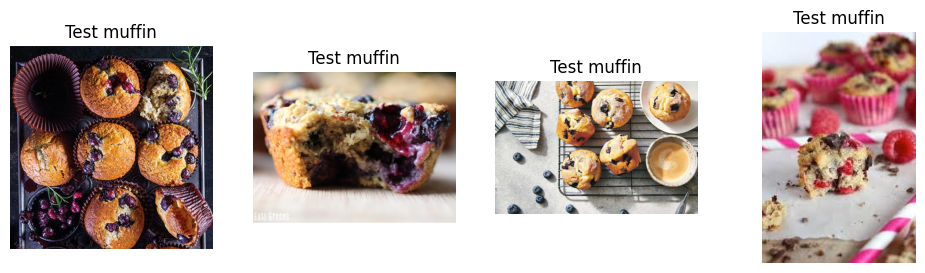

Test muffin 총 이미지 수:18


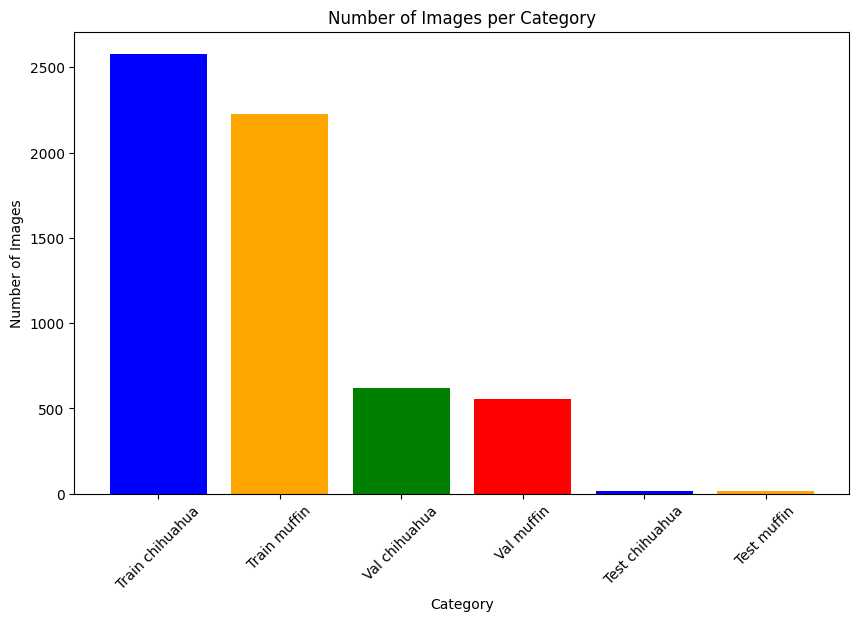

In [ ]:
# 이미지와 바 그래프 출력
categories = ['Train chihuahua', 'Train muffin', 'Val chihuahua', 'Val muffin', 'Test chihuahua', 'Test muffin']

for category in categories:
  image_paths = glob.glob(f'/content/muffin_vs_chihuahua/6/{category.lower().replace(" ","/")}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수:{len(image_paths)}")

# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/muffin_vs_chihuahua/6/{category.lower().replace(" ","/")}/*')) for category in categories], color=['blue', 'orange', 'green', 'red'])
plt.title('Number of Images per Category')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from imgaug import augmenters as iaa
import imgaug as ia

# imgaug를 활용한 데이터 증강(augmentation) 정의
class ImgAugTransform:
  def __init__(self):
    # 여러 증강 기법들을 순차적으로 적용 (Sequential)
    self.aug = iaa.Sequential([
        iaa.LinearContrast((0.75, 1.5)), # 대비 조절
        iaa.Crop(percent=(0, 0.2)), # 이미지의 0%에서 20% 까지 무작위로 잘라냄
        iaa.GaussianBlur(sigma=(0.0, 3.0)), # 가우시안 블러
        iaa.AdditiveGaussianNoise(scale=(10, 60)), # 가우시안 노이즈 추가
        iaa.Fliplr(0.5), # 50% 확률로 좌우 반전
        iaa.Flipud(0.2), # 20% 확률로 상하 반전
        iaa.Affine(rotate=(-20, 20)), # -20도에서 20도 사이로 회전
        iaa.Affine(scale=(0.5, 1.5)), # 50%에서 150% 사이로 확대/ 축소
    ])

  def __call__(self, img):
    # PIL Image -> Numpy 배열 (imgaug는 numpy만 처리 가능)
    img = np.array(img)
    # 정의한 증강 적용 후 반환
    return self.aug.augment_image(img)

# 커스텀 데이터셋 정의 (ImageFolder 상속)
class CustomDataset(ImageFolder):
  def __init__(self, root, imgaug=None, transform=None):
    """
    Args:
        root (str): 데이터셋 경로
        imgaug (callable): imgaug 변환 적용 여부
        transform (callable): torchvision.transforms
    """
    super(CustomDataset, self).__init__(root, transform=transform)
    self.imgaug_transform = imgaug # imgaug 변환기를 저장

  def __getitem__(self, index):
    # index번째 샘플의 (경로, 라벨) 불러오기
    path, target = self.samples[index]
    # 이미지 로딩 (PIL.Image 객체)
    img = self.loader(path)

    # 1. imgaug 변환 적용
    if self.imgaug_transform is not None:
      img = self.imgaug_transform(img) # numpy array 반환
      img = Image.fromarray(img) # 다시 PIL Image로 변환

    if self.transform is not None:
      img = self.transform(img)

    return img, target



In [ ]:
from torchvision import transforms

pytorch_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
# 데이터셋 및 데이터 로더 초기화
train_path = '/content/muffin_vs_chihuahua/6/train'
val_path = '/content/muffin_vs_chihuahua/6/val'

train_dataset = CustomDataset(train_path, imgaug=ImgAugTransform(), transform=pytorch_transforms)
val_dataset = CustomDataset(val_path, transform=pytorch_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
# DataLoader에서 샘플 이미지를 불러와 화면에 출력하는 함수
def imshow(img, size=(20,20), mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
  # (C, H, W) -> (H, W, C) 형태로 변환 (matplotlib은 HWC 형태를 요구)
  img = img.numpy().transpose((1,2,0))

  # mean과 std를 Numpy 배열로 변환 (정규화 복원을 위해)
  mean = np.array(mean)
  std = np.array(std)

  # 정규화 해제 (역정규화)
  # 원래 정규화: (x - mean) / std
  # 역정규화: (x * std) + mean
  img = std * img + mean

  # 이미지 픽셀 값을 [0, 1] 범위로 제한 (넘치거나 음수 값 방지)
  img = np.clip(img, 0, 1)

  # matplotlib으로 출력
  plt.figure(figsize=size)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

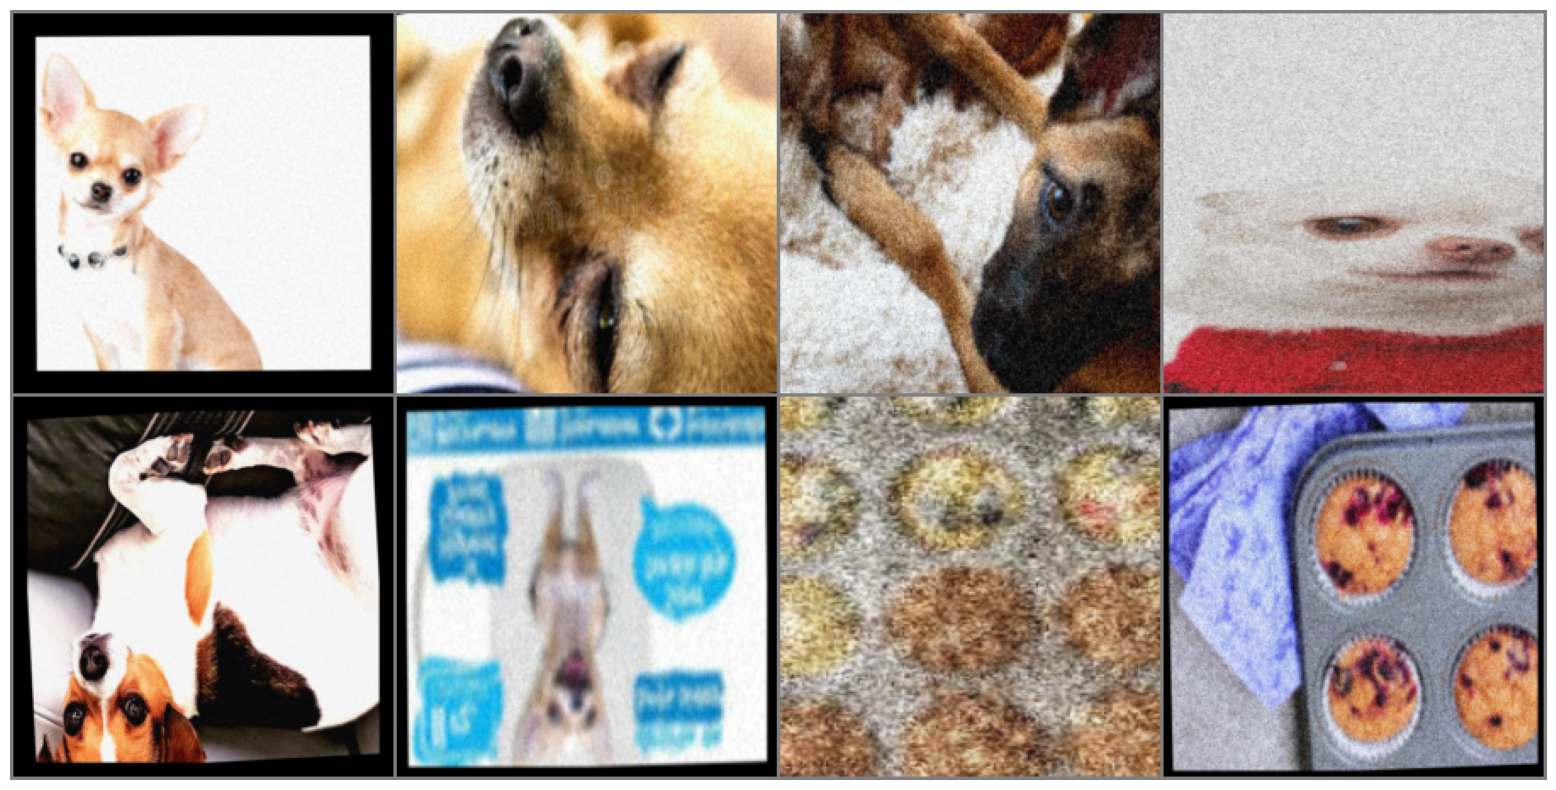

In [ ]:
# DataLoader에서 배치 단위 데이터 꺼내오기
dataiter = iter(train_loader)    # train_loader는 반복 가능한 객체 -> iter()로 이터레이터 생성
images, _ = next(dataiter)       # next()로 한 배치 추출 -> (이미지 텐서, 라벨)

imshow(make_grid(images[:8], nrow=4), size=(20, 10))

In [ ]:
class Bottleneck(nn.Module):
  # Bottleneck 블록은 출력 채널을 4배 확장하는 구조 (ResNet 논문 구조)
  expansion = 4

  def __init__(self, in_channels, out_channels, stride=1, downsample=None):
    super(Bottleneck, self).__init__()
    # 1x1 Conv: 채널 수를 줄이는 역할 (차원 축소)
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)

    # 3x3 Conv: 특징 추출 (stride를 조절해 크기 줄이기도 함)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    # 1x1 Conv: 채널 수를 다시 확장 (out_channels * expansion = 4배)
    self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion ,kernel_size=1, bias=False)
    self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

    # 활성화 함수 (ReLU)
    self.relu = nn.ReLU(inplace=True)

    # downsample: 입력 x의 크기/채널이 출력과 다를 때 맞춰주는 1x1 Conv 블록
    self.downsample = downsample

  def forward(self, x):
    # 잔차 연결용 identity
    identity = x

    # 1x1 Conv -> BN -> ReLU
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    # 3x3 Conv -> BN -> ReLU
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    # 1x1 Conv (채널 확장) -> BN
    out = self.conv3(out)
    out = self.bn3(out)

    # 입력과 출력의 크기/채널이 다르면 downsample로 identity를 변환
    if self.downsample is not None:
      identity = self.downsample(x)

    # skip connection: 변환된 입력(identity)과 출력(out)을 더함
    out += identity

    # 최종 ReLU
    out = self.relu(out)

    return out

In [ ]:
class ResNet(nn.Module):
  def __init__(self, block, layers, num_classes=1000):
    super(ResNet, self).__init__()

    # --- Stem: 입력 이미지를 빠르게 downsample해서 연산량 절감 ---
    # 입력: (N, 3, H, W)
    self.in_channels = 64
    self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    # --- Residual Steps: 특징을 점점 추상화 (공간 ↓, 채널 ↑)
    # 각 stage는 여러 개의 residual block으로 구성되고,
    # 첫 block에서만 stride로 공간 크기를 줄입니다.
    self.layer1 = self._make_layer(block, 64, layers[0])            # 출력 채널: 64 * expansion (Bottleneck=4) -> 256
    self.layer2 = self._make_layer(block, 128, layers[1], stride=2) # 출력 채널: 128 * 4 -> 512, 공간 1/2
    self.layer3 = self._make_layer(block, 256, layers[2], stride=2) # 출력 채널: 256 * 4 -> 1024, 공간 1/2
    self.layer4 = self._make_layer(block, 512, layers[3] ,stride=2) # 출력 채널: 512 * 4 -> 2048, 공간 1/2

    # --- Head: 공간 평균 -> 분류
    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.fc = nn.Linear(512 * block.expansion, num_classes)

  def _make_layer(self, block, out_channels, blocks, stride=1):
    """
    한 Stage를 생성.
    - 첫 블록: stride/다운샘플 적용으로 공간/채널 정렬
    - 이후 블록: 동일 공간/채널 유지
    """
    downsample = None

    # 입력 채널(self.in_channels)과 Stage 첫 블록의 출력 채널(out_channels*expansion)이 다르거나
    # stride로 공간 크기가 변할 때는, Skip 경로(identity)의  shape을 맞추기 위해 downsample(1x1 Conv+BN)을 준비.
    if stride != 1 or self.in_channels != out_channels * block.expansion:
      downsample = nn.Sequential(
          nn.Conv2d(self.in_channels, out_channels * block.expansion,
                    kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels * block.expansion),
      )

      layers = []
      # 첫 블록: (필요 시) 공간/채널을 바꾸면서 특징 추출
      layers.append(block(self.in_channels, out_channels, stride, downsample))
      # 이후 블록들의 입력 채널은 첫 블록의 출력 채널(= out_channels*expansion)로 갱신

      # 나머지 블록들: stride=1, downsample 없음 (이미 모양이 맞음)
      for _ in range(1, blocks):
        layers.append(block(self.in_channels, out_channels))

      return nn.Sequential(*layers)

